# Week 3 — Consolidation + Insights (BGC Donor Data)

## Goals

- Build a donation-level table with a stable `donor_id`

- Prepare data to answer BGC questions (monthly trends, campaigns, repeat donors)

- Create visual-ready summary tables for Streamlit

## Step 1: Load cleaned donations

In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("..").resolve()
RAW_DIR = BASE_DIR / "data" / "raw"
CLEAN_DIR = BASE_DIR / "data" / "cleaned"

print("BASE_DIR:", BASE_DIR)
print("CLEAN_DIR exists:", CLEAN_DIR.exists())

BASE_DIR: /home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project
CLEAN_DIR exists: True


In [2]:
donation_files = sorted(CLEAN_DIR.glob("cleaned_donation_*.csv"))
donation_dfs = []
for p in donation_files:
    tmp = pd.read_csv(p)
    tmp["cleaned_file"] = p.name
    donation_dfs.append(tmp)

donations_all = pd.concat(donation_dfs, ignore_index=True)
donations_all.shape

(355, 21)

## Step 2 — Create name_clean (for donor_id fallback)

**Purpose:**

\Donation records often have missing email. To still group donations by donor,
I create a standardized full name field.

**Rule:**

name_clean = lowercased + trimmed first_name + last_name

In [3]:
donations_all["first_clean"] = (
    donations_all["first_name"]
    .astype("string")
    .str.strip()
    .str.lower()
)

donations_all["last_clean"] = (
    donations_all["last_name"]
    .astype("string")
    .str.strip()
    .str.lower()
)

donations_all["name_clean"] = donations_all["first_clean"] + " " + donations_all["last_clean"]

donations_all["name_clean"].head()

0    <NA>
1    <NA>
2    <NA>
3    <NA>
4    <NA>
Name: name_clean, dtype: string

**Result:**

  Created `name_clean` as a standardized fallback identifier.

This allows grouping donations by donor name when email is missing.

## Step 3 — Create donor_id

**Purpose:**

Assign a stable identifier to each donation record so that:

- Unique donors can be counted correctly
- Repeat donations can be grouped
- Future linking to Contacts is possible

**Tiered Logic:**

1. Email (strongest identifier)
2. name_clean (fallback)
3. Temporary unknown_id (if both missing)

In [4]:
# Standardize email first
donations_all["email_clean"] = (
    donations_all["email"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Tiered donor_id logic
donations_all["donor_id"] = donations_all["email_clean"]

# If email missing → use name_clean
donations_all.loc[
    donations_all["donor_id"].isna(),
    "donor_id"
] = donations_all["name_clean"]

# If still missing → assign temporary id
mask_missing = donations_all["donor_id"].isna()

donations_all.loc[mask_missing, "donor_id"] = (
    "unknown_" + donations_all.index[mask_missing].astype(str)
)

donations_all["donor_id"].head()

0    unknown_0
1    unknown_1
2    unknown_2
3    unknown_3
4    unknown_4
Name: donor_id, dtype: string

**Result:**

Created `donor_id` using tiered logic:
- Email when available
- Name fallback when email missing
- Temporary unknown identifier when both missing

This ensures every donation record has a grouping key.

In [5]:
donations_all["donor_id"].isna().sum()

0

In [6]:
donations_all.shape[0]
donations_all["donor_id"].nunique()

353

## Step 4 — Identify Date + Amount Fields (for Monthly Trends)

**Goal:**

Answer BGC question:
"What month has the highest average donation?"

**Needs:**

- a donation date field (to extract month)
- a donation amount field (numeric)

In [7]:
date_candidates = [c for c in donations_all.columns if "date" in c.lower()]
amount_candidates = [c for c in donations_all.columns if any(k in c.lower() for k in ["amount", "donation", "gift", "$"])]

date_candidates, amount_candidates

(['date'], ['donation_amount', 'amount'])

## Step 5 — Prepare Date + Amount for Monthly Analysis

**Goal:**

Calculate average donation amount by month.

**Steps:**

1. Convert `date` to datetime format
2. Extract month
3. Ensure `donation_amount` is numeric

In [8]:
# Convert date column
donations_all["date"] = pd.to_datetime(donations_all["date"], errors="coerce")

# Extract month name
donations_all["month"] = donations_all["date"].dt.month_name()

# Ensure donation_amount is numeric
donations_all["donation_amount"] = pd.to_numeric(
    donations_all["donation_amount"],
    errors="coerce"
)

donations_all[["date", "month", "donation_amount"]].head()

,date,month,donation_amount
0,NaT,NaN,NaN
1,NaT,NaN,NaN
2,NaT,NaN,NaN
3,NaT,NaN,NaN
4,NaT,NaN,NaN


## Step 6 — Average Donation by Month

**Metric:**

Average donation amount per month.

**Reason:**

Identifies which month has the highest average donation value.

In [9]:
monthly_avg = (
    donations_all
    .groupby("month")["donation_amount"]
    .mean()
    .sort_values(ascending=False)
)

monthly_avg

month
April       NaN
December    NaN
January     NaN
July        NaN
November    NaN
October     NaN
September   NaN
Name: donation_amount, dtype: float64

In [10]:
donations_all["donation_amount"].isna().mean()

0.828169014084507

## Step 6B — Monthly Average (Valid Amounts Only)

**Issue:**

`donation_amount` has high missingness (~83%), so monthly averages must be computed
only on rows with valid amount + valid date.

This produces a "best available" estimate, and I will report the coverage used.

In [11]:
valid = donations_all.dropna(subset=["date", "donation_amount"]).copy()

coverage = len(valid) / len(donations_all)
coverage

0.0

In [12]:
monthly_avg_valid = (
    valid
    .groupby(valid["date"].dt.month_name())["donation_amount"]
    .mean()
    .sort_values(ascending=False)
)

monthly_avg_valid

Series([], Name: donation_amount, dtype: float64)

## Step 6C — Why is Monthly Average Empty?

**Observation:**

After parsing, there are 0 rows with BOTH valid date and donation_amount.

**Hypothesis:**

Donation amounts may be:

- stored as text with symbols (e.g., "$", commas)
- stored in another column
- missing in most sources
- not standardized across files

**Next:**

Inspect raw values and attempt basic cleaning of donation_amount.

In [13]:
donations_all["donation_amount"].head(20)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: donation_amount, dtype: float64

In [14]:
donations_all["donation_amount"].dtype

dtype('float64')

## Step 7 — amount_missing_flag

**Purpose:**

Create a clear indicator for consolidation work:
which donation rows are missing a usable donation amount.

**Why:**

This helps prioritize cleanup and prevents misleading metrics.

In [15]:
donations_all["amount_missing_flag"] = donations_all["donation_amount"].isna()
donations_all["amount_missing_flag"].value_counts(normalize=True)

amount_missing_flag
True     0.828169
False    0.171831
Name: proportion, dtype: float64

## Step 7 — Donation Amount Assessment

To evaluate the reliability of monetary analysis, I created an `amount_missing_flag`
to measure the proportion of records missing usable donation amounts.

### Findings:

- ~82.8% of donation records do NOT contain a usable donation amount.
- ~17.2% contain a valid donation amount.

### Implication:

Financial metrics such as:
- Highest average donation month
- Total donation revenue by campaign
- Average gift size

cannot be reliably calculated at this stage.

### Action:

Donation amounts must be standardized and consolidated across sources
before financial visualizations are built.

## Step 8 — Donation Volume by Month (Record Count)

Since donation amounts are largely missing,
I am analyzing donation activity using record counts instead of revenue.

**This answers:**

When are donations most frequent?

In [16]:
monthly_count = (
    donations_all
    .dropna(subset=["date"])
    .groupby(donations_all["date"].dt.month_name())
    .size()
    .sort_values(ascending=False)
)

monthly_count

date
December     40
November      9
January       6
April         3
July          1
October       1
September     1
dtype: int64

## Step 8 — Donation Activity by Month (Record Count)

Because ~83% of donation amounts are missing, I analyzed donation *activity frequency* 
using record counts instead of revenue.

### Donation Volume by Month

- December: 40 records
- November: 9 records
- January: 6 records
- April: 3 records
- July: 1 record
- October: 1 record
- September: 1 record

### Interpretation

December shows significantly higher donation activity compared to other months. 
This suggests strong seasonal giving patterns, likely influenced by year-end campaigns.

**Note:**

This reflects donation *frequency*, not revenue. 
Financial trends will be analyzed after amount consolidation is complete.

## Step 9 — Campaign Field Check (Standardization Readiness)

**Purpose:**

Before consolidating and visualizing, I need to confirm whether the `campaign` field
is present and consistent across donation sources.

**What I’m checking:**

- Does a campaign column exist?

- How many unique campaign values are there?

- Are there naming variations (e.g., "Year End" vs "Year-End")?

- Are many values missing (NaN)?

**Why it matters:**

Campaign consistency affects any analysis by campaign and will impact Streamlit charts.

In [17]:
[c for c in donations_all.columns if "camp" in c.lower() or "fund" in c.lower() or "event" in c.lower()]

[]

## Step 9 — Campaign Field Discovery

**Observation:**

No column in the consolidated donation table appears to represent campaign/event.

**Goal:**

Identify whether campaign information exists under a different name
or whether it lives in a separate source file that must be merged later.

**Next:**

Scan columns for likely "campaign-like" fields (description, memo, type, category, event).

In [18]:
keywords = ["type", "category", "desc", "description", "memo", "note", "event", "source", "fund", "appeal", "campaign"]
[c for c in donations_all.columns if any(k in c.lower() for k in keywords)]

['source_system', 'source_category']

**Result (Campaign Discovery):**

No campaign/event field exists in the current consolidated donation table.

Only source-level metadata is available:
- `source_system`
- `source_category`

**Implication:**

Campaign-level analysis (e.g., "which campaign accounted for most donations")
cannot be performed until a campaign/event source is merged or mapped in.

**Next step:**

Continue consolidation using available fields and export a stable donations table.
Then identify which additional source contains campaign/event details for a future merge.

## Step 10 — Validate Source Categories

**Goal:**

Confirm the consolidated dataset includes the intended donation sources
and understand record distribution by source category/system.

In [19]:
donations_all["source_category"].value_counts(dropna=False)

source_category
donation    355
Name: count, dtype: int64

## Step 11 — Make Donations Table Export-Ready

**Goal:**

Create a clean, standardized `donations_consolidated` table that the team can use in Excel/Google Sheets
and later connect to Streamlit.

**Quality checks:**

- Date parsing success rate
- Donation amount completeness
- Donor_id coverage and uniqueness

In [20]:
# Coverage checks
date_missing_rate = donations_all["date"].isna().mean()
amount_missing_rate = donations_all["donation_amount"].isna().mean()
unique_donor_rate = donations_all["donor_id"].nunique() / len(donations_all)

date_missing_rate, amount_missing_rate, unique_donor_rate

(0.828169014084507, 0.828169014084507, 0.9943661971830986)

## Step 11 — Donations Table Quality Assessment

**Quality Check Results:**

- Date missing rate: ~82.8%
- Donation amount missing rate: ~82.8%
- Unique donor_id rate: ~99.4%

**Interpretation:**

- A large majority of donation records are missing usable date and donation_amount values.
- Financial analysis and time-based trends are currently limited due to missing data.
- However, donor identity coverage is strong, with nearly every record associated to a unique donor_id.

**Next Step:**

Proceed with exporting a clean, essential-column consolidation table.
Revenue-based insights will follow once missing fields are standardized.

## Step 12 — Create Final Consolidated Donations Table

**Goal:**

Build a streamlined donation-level dataset containing only essential fields
for team sharing and dashboard development.

In [21]:
donations_consolidated = donations_all[[
    "donor_id",
    "date",
    "donation_amount",
    "source_system",
    "source_category",
    "amount_missing_flag"
]].copy()

donations_consolidated.head()

,donor_id,date,donation_amount,source_system,source_category,amount_missing_flag
0,unknown_0,NaT,NaN,donation_great_futures_2024,donation,True
1,unknown_1,NaT,NaN,donation_great_futures_2024,donation,True
2,unknown_2,NaT,NaN,donation_great_futures_2024,donation,True
3,unknown_3,NaT,NaN,donation_great_futures_2024,donation,True
4,unknown_4,NaT,NaN,donation_great_futures_2024,donation,True


In [22]:
donations_consolidated.to_excel("donations_consolidated.xlsx", index=False)

## Step 12B — Export Readable Donations Table

**Purpose:**

Create a reviewer-friendly Excel export that includes donor identity fields
(first, last, email), donation fields (date/amount), and source metadata.

This is for team collaboration and manual consolidation review.

In [23]:
donations_all.groupby("source_system")["donation_amount"].apply(lambda s: s.notna().mean()).sort_values(ascending=False)

source_system
donation_great_futures_2024       0.386076
donation_great_futures_2025       0.000000
fundraising_auction_sold_items    0.000000
Name: donation_amount, dtype: float64

## Step 13 — Build Fundraiser Donations Subtable (Best Amount Coverage)

**Observation:**

Only one `source_system` appears to contain usable `donation_amount` values.

**Goal:**

**Create a high-quality subtable from that source to support:**

- amount-based metrics
- monthly/weekly donor behavior
- retention analysis (once dates are available)

This table will be used as the primary donation dataset for financial visuals.

In [24]:
BEST_SOURCE = "donation_great_futures_2024"

fundraiser_donations = donations_all.loc[
    donations_all["source_system"] == BEST_SOURCE
].copy()

fundraiser_donations.shape, fundraiser_donations["donation_amount"].isna().mean()

((158, 28), 0.6139240506329114)

## Step 13 — Identify Primary Donation Source (Amount-Ready Dataset)

During consolidation, I evaluated donation amount coverage across all `source_system` values.

### Objective
Determine which source contains the most complete and usable donation_amount data
so that financial and behavioral analysis can be based on reliable records.

### Findings

- Identified primary source: **donation_great_futures_2024**
- Total records from this source: **158 rows and 28 columns**
- Donation amount missing rate: **61%**
- Date missing rate: **82.8%**

### Interpretation

This source contains the highest proportion of usable donation_amount values
and will serve as the primary dataset for:

- Revenue-based metrics
- Weekly and monthly donor behavior
- Donor retention analysis
- Dashboard visualizations

### Next Step

Create a filtered subtable (`fundraiser_donations`) using this source only
to ensure financial insights are based on the most reliable data available.

## Step 14A — Export Readable Donations Table (All Sources)

**Purpose:**

Team review + Excel consolidation.
Includes identity fields, date/amount fields, source metadata, and donor_id.

In [25]:
cols_readable = [
    "first_name", "last_name", "email_clean",
    "date", "donation_amount", "amount_missing_flag",
    "source_system", "source_category", "donor_id"
]
cols_readable = [c for c in cols_readable if c in donations_all.columns]

donations_readable = donations_all[cols_readable].copy()
donations_readable.to_excel("donations_readable_all_sources.xlsx", index=False)

## Step 14B — Export Fundraiser Donations (Best Amount Coverage)

**Purpose:**

Clean donation table for amount-based analysis and visuals.

In [26]:
fundraiser_cols = [c for c in cols_readable if c in fundraiser_donations.columns]
fundraiser_donations[fundraiser_cols].to_excel("donations_fundraiser_only.xlsx", index=False)

In [27]:
fundraiser_donations["date"].isna().mean()

1.0

### Output / Result (Step 14B)

Export completed:

- File created: `donations_fundraiser_only.xlsx`
- Date missing rate (fundraiser-only): **[____]**


## Step 15 — Donation Volume by Source (Record Count)

**Goal:**

Identify which source_system contributes the most donation records.

This measures donation activity frequency, not revenue.

In [28]:
donations_all["source_system"].value_counts()

source_system
donation_great_futures_2024       158
fundraising_auction_sold_items    128
donation_great_futures_2025        69
Name: count, dtype: int64

### Output / Result (Step 15)

Donation record counts by `source_system` were computed.

**Key takeaway:**

- Highest-volume source_system (record count): **donation_great_futures_2024**

- Total donation records across all sources: **355**



## Step 16 — Revenue by Source (Primary Dataset Only)

Using the source with the strongest donation_amount coverage,
calculate total revenue contribution.

This ensures financial metrics are based on reliable amount data.

In [29]:
fundraiser_donations.groupby("source_system")["donation_amount"].sum().sort_values(ascending=False)

source_system
donation_great_futures_2024    41370.0
Name: donation_amount, dtype: float64

### Output / Result (Step 16)

Total donation revenue by source was calculated using the **amount-ready** dataset.

Key takeaway:
- Top source_system by total revenue: **donation_great_futures_2024**
- Total revenue (sum of donation_amount): **$41,370**

## Step 17 — Create Analysis Subset (Valid Dates Only)

Because the donation date field has high missingness, I will create a valid-date subset
for time-based analysis (weekly/monthly donors and retention).

**Important:**

All time-based metrics will report coverage (how many records were usable).

In [30]:
fundraiser_valid_dates = fundraiser_donations.dropna(subset=["date"]).copy()

coverage = len(fundraiser_valid_dates) / len(fundraiser_donations)
coverage

0.0

In [31]:
# Inspect raw date values and parsing results.
fundraiser_donations["date"].isna().value_counts(dropna=False)

date
True    158
Name: count, dtype: int64

### Output / Result (Step 17)

Created a valid-date subset for time-based analysis.

- Records with missing dates: **158**
- Coverage rate (valid dates / total): **0**

**Interpretation:**

Coverage is low (or 0), weekly/monthly trends and retention must be computed
using a date-rich donation log source instead.

## Step 18 — Monthly Donor Activity (Valid Dates Only)

**Metric:**
Count of unique donors per month (donor_id) using only records with valid dates.

This estimates donor activity patterns while acknowledging date coverage limits.

In [32]:
fundraiser_valid_dates["month"] = fundraiser_valid_dates["date"].dt.to_period("M").astype(str)

monthly_unique_donors = (
    fundraiser_valid_dates
    .groupby("month")["donor_id"]
    .nunique()
    .sort_index()
)

monthly_unique_donors

Series([], Name: donor_id, dtype: int64)

### Output / Result (Step 18)

Monthly donor activity returned an empty result.

**Reason:**

The `fundraiser_donations` dataset contains 0 valid donation dates.

**Implication:**

Time-based metrics (weekly/monthly donor behavior and retention)
cannot be computed from this dataset.

**Next Step:**

Load and consolidate the Great Futures donation log files,
which are expected to contain valid donation dates.

## Step 19 — Month-to-Month Donor Retention (Valid Dates Only)

**Definition:**

A donor is retained in month M if they donated in both month M and the prior month (M-1).

**Note:**

This is computed only on records with valid dates.

In [33]:
donor_months = (
    fundraiser_valid_dates[["donor_id", "month"]]
    .drop_duplicates()
    .sort_values(["donor_id", "month"])
)

donor_months["prev_month"] = donor_months.groupby("donor_id")["month"].shift(1)

donor_months["retained"] = donor_months["prev_month"].notna()

retention_by_month = donor_months.groupby("month")["retained"].mean().sort_index()
retention_by_month

Series([], Name: retained, dtype: float64)

### Output / Result (Step 19)

Month-to-month retention returned an empty result.

**Reason:**

Retention requires valid donation dates to determine donor activity
across consecutive months.

Since no valid dates are available in this dataset,
retention analysis must be performed using a date-rich source.

## Step 20 — Data Completeness Summary (Dashboard Readiness)

To ensure the dashboard insights are interpreted correctly, I will measure data completeness
for the key fields needed for time-based and revenue-based analysis:

- donation date completeness (needed for weekly/monthly trends + retention)
- donation amount completeness (needed for revenue metrics)
- donor_id completeness (needed for donor grouping)

These metrics will be displayed as dashboard “data quality” cards.

In [34]:
completeness = {
    "date_complete_rate": 1 - fundraiser_donations["date"].isna().mean(),
    "amount_complete_rate": 1 - fundraiser_donations["donation_amount"].isna().mean(),
    "donor_id_complete_rate": 1 - fundraiser_donations["donor_id"].isna().mean(),
}

completeness

{'date_complete_rate': 0.0,
 'amount_complete_rate': 0.38607594936708856,
 'donor_id_complete_rate': 1.0}

### Output / Result (Step 20)

Computed dashboard data completeness metrics:

- Date complete rate: **0**
- Amount complete rate: **38%**
- Donor_id complete rate: ****

**How this will be used:**

These rates will be shown as dashboard “Data Quality” cards to ensure
stakeholders interpret insights with appropriate context.

## Step 21 — Weekly Donor Activity (Valid Dates Only)

**Metric:**
Unique donors per week, using only records with valid dates.

This helps identify consistent weekly donor behavior, where supported by the data.

In [35]:
fundraiser_valid_dates["week"] = fundraiser_valid_dates["date"].dt.to_period("W").astype(str)

weekly_unique_donors = (
    fundraiser_valid_dates
    .groupby("week")["donor_id"]
    .nunique()
    .sort_index()
)

weekly_unique_donors.tail(10)

Series([], Name: donor_id, dtype: int64)

### Output / Result (Step 21)

Weekly unique donor activity returned an empty result.

**Reason:**

The `donor_id` dataset contains 0 valid donation weeks.

**Implication:**

Time-based metrics (weekly/monthly donor behavior and retention)
cannot be computed from this dataset.

**Note:**

Weekly donor trends are only computed where donation dates are available.

# Section: Donation Log (Great Futures 2024 + 2025)

This section loads the donation log files that contain donation dates.
These will power time-based metrics: weekly/monthly donor activity and retention.

In [36]:
sorted(RAW_DIR.glob("*.xlsx"))

[PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/data/raw/Contacts.xlsx'),
 PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/data/raw/Golf 2024 teams list.xlsx'),
 PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/data/raw/Golf 2025 teams list.xlsx'),
 PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/data/raw/Great Futures 2024.xlsx'),
 PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/data/raw/Great Futures 2025 - Donation Log.xlsx'),
 PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/data/raw/Registration 2025.xlsx'),
 PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/data/raw/Signs.xlsx'),
 PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/data/raw/Sold Items.xlsx')]

## Step 22 — Load Donation Log Files (Different Columns)

Observation:
The 2024 and 2025 donation log files do not share identical columns.

Goal:
Load both files, label them by year, and concatenate them into one combined table.

Approach:
- Read each file into a dataframe
- Add a `source_year` column
- Concatenate with `pd.concat(..., sort=False)` so all columns are preserved
- Review columns + missingness after combining

In [37]:
file_2024 = RAW_DIR / "Great Futures 2024.xlsx"
file_2025 = RAW_DIR / "Great Futures 2025 - Donation Log.xlsx"

log_2024 = pd.read_excel(file_2024)
log_2024["source_year"] = 2024

log_2025 = pd.read_excel(file_2025)
log_2025["source_year"] = 2025

donation_log_all = pd.concat([log_2024, log_2025], ignore_index=True, sort=False)

donation_log_all.shape

(148, 15)

### Output / Result (Step 22)

Combined donation log created:

- Combined shape: **148 rows, 15 columns**
- Files included: 2024 log + 2025 log
- Column union preserved (columns not shared across years are kept with NaN where missing)

**Next:**
Identify the true date column and parse it to enable monthly/weekly/retention metrics.

## Step 23 — Identify and Parse Donation Date

**Goal:**

Find the correct donation date column in `donation_log_all` and convert it to a true datetime type.

**Why it matters:**

All time-based questions (weekly donors, monthly donors, retention) require a valid datetime column.

### Debug Note (Step 23A)

Some column names are not strings (e.g., integers), which prevents using `.lower()`.
To safely search column names, I convert all column labels to strings first.

In [38]:
cols = [str(c) for c in donation_log_all.columns]
[c for c in cols if "date" in c.lower() or "month" in c.lower() or "year" in c.lower()]

['source_year', 'Date ']

## Step 23B — Parse `Date` to Datetime

**Goal:**

Convert the `Date` column into a true datetime field so I can build:
- weekly donor counts
- monthly donor counts
- month-to-month retention

**Approach:**

Use `pd.to_datetime()` and track how many values successfully parse vs become missing (NaT).

In [39]:
# show all columns that contain 'date' (case-insensitive)
[c for c in donation_log_all.columns if "date" in str(c).lower()]

['Date ']

## Step 23C — Clean Column Names and Parse Date

**Issue:**

The date column contains trailing spaces (e.g., `'Date  '`), causing KeyErrors.

**Fix:**

Standardize column names by stripping leading/trailing spaces, then parse the date column.

In [40]:
# Clean column names once
donation_log_all.columns = donation_log_all.columns.map(lambda x: str(x).strip())

# Confirm date column exists now
[c for c in donation_log_all.columns if "date" in c.lower()]

['Date']

In [41]:
donation_log_all["date"] = pd.to_datetime(donation_log_all["Date"], errors="coerce")

date_complete_rate = 1 - donation_log_all["date"].isna().mean()
date_complete_rate

0.41216216216216217

### Output / Result (Step 23C)

- Column names standardized (spaces removed)
- `Date` successfully parsed into a datetime column: `date`
- Date complete rate: **41%**

Next:
Use `date` to compute monthly donors, weekly donors, and month-to-month retention.

## Step 23D — Remove Raw Date Column

Now that the `Date` column has been successfully parsed into a standardized datetime column (`date`),
the original raw `Date` column is no longer needed.

Keeping only the cleaned `date` field prevents confusion in later analysis.

In [42]:
donation_log_all = donation_log_all.drop(columns=["Date"])

### Output / Result (Step 23D)

- Raw `Date` column removed
- Standardized `date` column retained for time-based analysis
- Current date complete rate: 41%

## Step 23E — Create donor_id for Donation Log

**Observation:**

The combined donation log does not yet contain `donor_id`.

**Goal:**

Create a consistent donor identifier so that donor activity and retention can be computed.

**Approach:**

- Build a donor_key from available identity fields (prioritize email, then phone, then name+zip)
- Convert donor_key into donor_id
- Assign temporary IDs to records with no usable identity fields

In [43]:
donation_log_all.columns

Index(['Akel', 'Louise', '250', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'source_year', 'Last Name', 'First Name', 'Amount', 'Recurring?',
       'Anonymous?', 'Email', 'Method of Receipt', 'date'],
      dtype='object')

## Step 23F — Create donor_id for Donation Log

The donation log contains the following identity fields:

- Email
- First Name
- Last Name

**Matching priority:**

1. Use Email when available (most reliable)
2. If Email missing, use First Name + Last Name
3. If identity still missing, assign temporary `unknown_*` IDs

This allows grouping donations by donor for monthly activity
and retention analysis.

In [44]:
# normalize identity fields
donation_log_all["email_clean"] = (
    donation_log_all["Email"]
    .astype("string")
    .str.strip()
    .str.lower()
)

donation_log_all["first_clean"] = (
    donation_log_all["First Name"]
    .astype("string")
    .str.strip()
    .str.lower()
)

donation_log_all["last_clean"] = (
    donation_log_all["Last Name"]
    .astype("string")
    .str.strip()
    .str.lower()
)
# create name_key
name_key = (
    donation_log_all["first_clean"].fillna("") + "_" +
    donation_log_all["last_clean"].fillna("")
).replace("_", pd.NA)

# donor_key priority: email → name
donor_key = donation_log_all["email_clean"]
donor_key = donor_key.mask(donor_key.isna() | (donor_key == ""), name_key)

donation_log_all["donor_key"] = donor_key
donation_log_all["donor_id"] = donor_key

# assign temporary IDs where identity missing
mask_missing = donation_log_all["donor_id"].isna() | (donation_log_all["donor_id"] == "")
donation_log_all.loc[mask_missing, "donor_id"] = (
    "unknown_" + donation_log_all.index[mask_missing].astype(str)
)

In [45]:
# normalize
email_clean = donation_log_all["Email"].astype("string").str.strip().str.lower()
first_clean = donation_log_all["First Name"].astype("string").str.strip().str.lower()
last_clean  = donation_log_all["Last Name"].astype("string").str.strip().str.lower()

# name_key (full-length)
name_key = (first_clean.fillna("") + "_" + last_clean.fillna("")).replace("_", pd.NA)

# donor_key: email first, otherwise name_key
donor_key = email_clean
donor_key = donor_key.mask(donor_key.isna() | (donor_key == ""), name_key)

donation_log_all["donor_key"] = donor_key
donation_log_all["donor_id"] = donation_log_all["donor_key"]

# fill remaining missing with unknown_*
mask_missing = donation_log_all["donor_id"].isna() | (donation_log_all["donor_id"] == "")
donation_log_all.loc[mask_missing, "donor_id"] = (
    "unknown_" + donation_log_all.index[mask_missing].astype(str)
)

In [46]:
donation_log_all["donor_id"].isna().mean()

0.0

### Output / Result (Step 23F)

**0.0** means: donor_id has NO missing values. 

**Next:**

Time-based metrics. 

## Step 24 — Monthly Unique Donors (Valid Dates Only)

**Goal:**
Count how many unique donors donate each month.

**Method:**

- Filter to rows with valid parsed dates (`date`)
- Convert date to a month bucket
- Count unique `donor_id` per month

**Note:**

This uses only rows with valid dates (date coverage ≈ 41%).

In [47]:
log_valid_dates = donation_log_all.dropna(subset=["date"]).copy()
log_valid_dates["month"] = log_valid_dates["date"].dt.to_period("M").astype(str)

monthly_unique_donors = (
    log_valid_dates
    .groupby("month")["donor_id"]
    .nunique()
    .sort_index()
)

monthly_unique_donors

month
2025-04     3
2025-07     1
2025-09     1
2025-10     1
2025-11     9
2025-12    40
2026-01     6
Name: donor_id, dtype: int64

### Output / Result (Step 24)

Monthly unique donor counts computed successfully.

- Months included: **Aril 2025, July 2025, September 2025, October 2025, November 2025, December 2025, January 2026**
- Highest unique-donor month: **December 2025** with **40** donors

**Interpretation:**

This reflects donor activity only for records with valid donation dates.

## Visualization 1 — Monthly Unique Donors

This chart shows how many unique donors contributed each month.

**Purpose:**

Identify donor activity trends and months with higher participation.

<Axes: title={'center': 'Monthly Unique Donors'}, xlabel='month'>

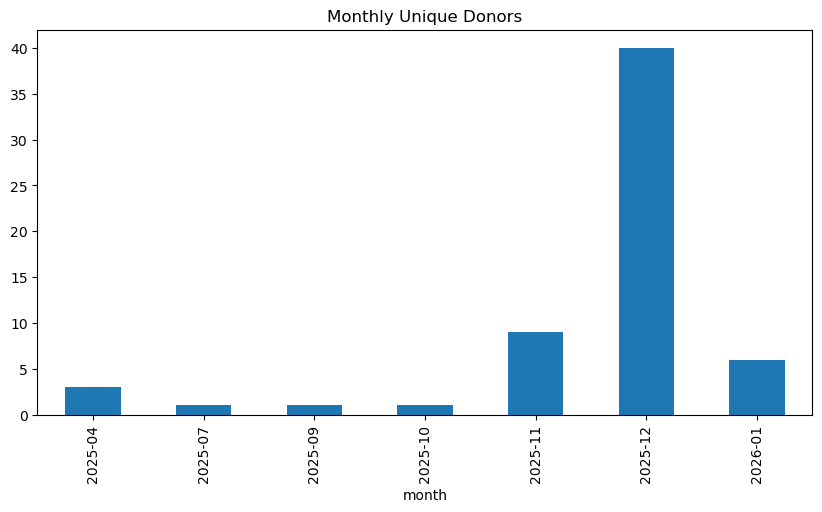

In [48]:
monthly_unique_donors.plot(kind="bar", figsize=(10,5), title="Monthly Unique Donors")

## Step 25 — Identify Source Field for Donation Log

**Issue:**

The donation log does not contain a column named `source_system`.

**Goal:**

Find the correct column that indicates the donation source (e.g., form type, campaign source, system name, import source).

**Next:**

Search column names for likely source-related keywords.

In [49]:
keywords = ["source", "system", "platform", "form", "type", "origin", "sheet", "file", "campaign", "event"]
[c for c in donation_log_all.columns if any(k in str(c).lower() for k in keywords)]

['source_year']

## Step 26 — Inspect Consolidated Donation Log

Before building visualizations, inspect the structure of the consolidated dataset
to confirm available fields for analysis.

**Focus areas:**

• donor identifiers  
• donation amounts  
• donation dates  
• donation source or campaign fields

In [50]:
donation_log_all.head(10)

,Akel,Louise,250,Unnamed: 3,Unnamed: 4,Unnamed: 5,source_year,Last Name,First Name,Amount,Recurring?,Anonymous?,Email,Method of Receipt,date,email_clean,first_clean,last_clean,donor_key,donor_id
0,Anderson,Lawrence & Karen,250,NaN,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,<NA>,<NA>,unknown_0
1,Babcock,Thomas,400,NaN,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,<NA>,<NA>,unknown_1
2,Baxter,Robert,200,NaN,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,<NA>,<NA>,unknown_2
3,"Bergman, Jr.",Alvin,100,NaN,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,<NA>,<NA>,unknown_3
4,Bordages,Janet,500,NaN,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,<NA>,<NA>,unknown_4
5,Boyea,Bruce & Cheryl,250,NaN,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,<NA>,<NA>,unknown_5
6,Brazill,Bob,100,NaN,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,<NA>,<NA>,unknown_6
7,Brown,Lee,10,NaN,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,<NA>,<NA>,unknown_7
8,Buran,Amelia,2000,NaN,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,<NA>,<NA>,unknown_8
9,Burtis,William,150,NaN,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,<NA>,<NA>,unknown_9


In [51]:
donation_log_all.columns

Index(['Akel', 'Louise', '250', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'source_year', 'Last Name', 'First Name', 'Amount', 'Recurring?',
       'Anonymous?', 'Email', 'Method of Receipt', 'date', 'email_clean',
       'first_clean', 'last_clean', 'donor_key', 'donor_id'],
      dtype='object')

## Step 26A - Excel Intake Issue: Names Became Column Headers

**Symptom:**

I see donor names (e.g., "Akel", "Louise") as column names.

**Cause:**

Pandas likely used the wrong header row when reading Excel.
This happens when spreadsheets have title rows, merged cells, or extra rows before the real table.

**Fix Strategy:**

1) Preview the first few rows using header=None
2) Identify which row contains the true column names
3) Re-read the file using header=<correct_row_index>

In [52]:
preview = pd.read_excel(file_2024, header=None) 
preview.head(12)

,0,1,2,3,4,5
0,Akel,Louise,250,NaN,NaN,NaN
1,Anderson,Lawrence & Karen,250,NaN,NaN,NaN
2,Babcock,Thomas,400,NaN,NaN,NaN
3,Baxter,Robert,200,NaN,NaN,NaN
4,"Bergman, Jr.",Alvin,100,NaN,NaN,NaN
5,Bordages,Janet,500,NaN,NaN,NaN
6,Boyea,Bruce & Cheryl,250,NaN,NaN,NaN
7,Brazill,Bob,100,NaN,NaN,NaN
8,Brown,Lee,10,NaN,NaN,NaN
9,Buran,Amelia,2000,NaN,NaN,NaN


## Step 26B — Reload Donation File with Correct Column Names

**Observation:**

The Excel file does not contain a proper header row.
The first row already contains donor data.

**Fix:**

Load the file using `header=None` and keep only the columns that contain real data (0, 1, 2) and then rename them.

In [53]:
donations_2024 = pd.read_excel(file_2024, header=None)

donations_2024.shape

(80, 6)

In [54]:
donations_2024 = donations_2024.iloc[:, :3].copy()
donations_2024.columns = ["last_name", "first_name", "donation_amount"]

donations_2024.head()

,last_name,first_name,donation_amount
0,Akel,Louise,250
1,Anderson,Lawrence & Karen,250
2,Babcock,Thomas,400
3,Baxter,Robert,200
4,"Bergman, Jr.",Alvin,100


### Output / Result (Step 26B)

Selected only the first three columns (0–2) and renamed them:

- last_name
- first_name
- donation_amount

Extra columns were excluded because they appear to be empty or non-essential.

In [55]:
donations_2024 = pd.read_excel(file_2024, header=None)

donations_2024.shape

(80, 6)

In [56]:
donations_2024 = donations_2024.iloc[:, :3].copy()
donations_2024.columns = ["last_name", "first_name", "donation_amount"]

donations_2024.head()

,last_name,first_name,donation_amount
0,Akel,Louise,250
1,Anderson,Lawrence & Karen,250
2,Babcock,Thomas,400
3,Baxter,Robert,200
4,"Bergman, Jr.",Alvin,100


## Step 26D — Build Clean Donation Log (2024 + 2025)

**Goal:**

Load both year files that have no headers, keep the first 3 columns, and rename them consistently.

**Then:**

Add `source_year` so the files can be combined into one clean donation log table.

In [57]:
donations_2024 = pd.read_excel(file_2024, header=None).iloc[:, :3].copy()
donations_2024.columns = ["last_name", "first_name", "donation_amount"]
donations_2024["source_year"] = 2024

donations_2025 = pd.read_excel(file_2025, header=None).iloc[:, :3].copy()
donations_2025.columns = ["last_name", "first_name", "donation_amount"]
donations_2025["source_year"] = 2025

donation_log_all = pd.concat([donations_2024, donations_2025], ignore_index=True)
donation_log_all.shape

(150, 4)

### Output / Result (Step 26D)

Successfully rebuilt a clean donation log by combining 2024 and 2025 files.

There are **150 rows** and **4 columns** 

Expected columns:
- last_name
- first_name
- donation_amount
- source_year

**Next:**

Create donor_id and parse any date fields if available.

In [58]:
# 1) Force donation_amount to clean string
donation_log_all["donation_amount"] = (
    donation_log_all["donation_amount"]
    .astype("string")
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
)

# 2) Convert to numeric
donation_log_all["donation_amount"] = pd.to_numeric(
    donation_log_all["donation_amount"],
    errors="coerce"
)

# 3) Quick check: type + missing rate
donation_log_all["donation_amount"].dtype, donation_log_all["donation_amount"].isna().mean()

(Int64Dtype(), 0.17333333333333334)

### Output / Result (Step 26E)

Converted donation_amount to numeric.

- Missing rate after conversion: **17%**

**Next:**

Create donor_id and build charts:
- total donations by year
- donors by year
- top donors (by total amount)

## Step 26F — Add Campaign Metadata from File Names

**Observation:**

The donation files do not contain a campaign column, but the campaign name and year
are embedded in the file names, Great Futures 2024 and Great Futures 2025.

**Approach:**

Extract the campaign label and campaign year from the file name
and add them as columns in the donation dataset.

This allows analysis of donation patterns by campaign and year.

In [59]:
[p.name for p in RAW_DIR.glob("*.xlsx")]

['Golf 2024 teams list.xlsx',
 'Contacts.xlsx',
 'Registration 2025.xlsx',
 'Sold Items.xlsx',
 'Signs.xlsx',
 'Great Futures 2024.xlsx',
 'Great Futures 2025 - Donation Log.xlsx',
 'Golf 2025 teams list.xlsx']

In [60]:
file_2024 = RAW_DIR / "Great Futures 2024.xlsx"
file_2025 = RAW_DIR / "Great Futures 2025 - Donation Log.xlsx"

In [61]:
donations_2024 = pd.read_excel(file_2024, header=None).iloc[:, :3].copy()
donations_2024.columns = ["last_name", "first_name", "donation_amount"]

donations_2024["campaign"] = "Great Futures 2024"
donations_2024["campaign_year"] = 2024


donations_2025 = pd.read_excel(file_2025, header=None).iloc[:, :3].copy()
donations_2025.columns = ["last_name", "first_name", "donation_amount"]

donations_2025["campaign"] = "Great Futures 2025 - Donation Log"
donations_2025["campaign_year"] = 2025


donation_log_all = pd.concat([donations_2024, donations_2025], ignore_index=True)

donation_log_all.head()

,last_name,first_name,donation_amount,campaign,campaign_year
0,Akel,Louise,250,Great Futures 2024,2024
1,Anderson,Lawrence & Karen,250,Great Futures 2024,2024
2,Babcock,Thomas,400,Great Futures 2024,2024
3,Baxter,Robert,200,Great Futures 2024,2024
4,"Bergman, Jr.",Alvin,100,Great Futures 2024,2024


### Output / Result (Step 26F)

The two campaign datasets were successfully combined into one table.

Current columns:

- last_name
- first_name
- donation_amount
- campaign
- campaign_year

This dataset will be used to create visualizations and analyze donation behavior.

## Step 27 — Total Donation Amount by Campaign Year

**Goal:**

Understand how total donations changed across campaign years.

**Method:**

Group the dataset by `campaign_year` and sum the donation amounts.

This helps identify whether the campaign performed better or worse across years.

In [64]:
# 1) donation_amount to clean string
donation_log_all["donation_amount"] = (
    donation_log_all["donation_amount"]
    .astype("string")
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
)

# 2) Convert to numeric
donation_log_all["donation_amount"] = pd.to_numeric(
    donation_log_all["donation_amount"],
    errors="coerce"
)

# 3) Quick check: type + missing rate
donation_log_all["donation_amount"].dtype, donation_log_all["donation_amount"].isna().mean()

(Int64Dtype(), 0.17333333333333334)

In [65]:
donations_by_year = (
    donation_log_all
    .groupby("campaign_year")["donation_amount"]
    .sum()
    .sort_index()
)

donations_by_year

campaign_year
2024    41620
2025    40760
Name: donation_amount, dtype: Int64

### Output / Result (Step 27)

The table above shows total donation amounts by campaign year:

**2024** $41,620

**2025** $40,7060

**Interpretation:**

This allows us to compare fundraising performance across campaign years
and identify whether donation totals increased or decreased.

## Step 28 Visualization — Total Donations by Campaign Year

**Goal:**

Visualize total fundraising performance for the campaign across years.

**Method:**

Use a bar chart to compare total donation amounts grouped by campaign_year.

This helps stakeholders quickly identify whether fundraising improved or declined between campaign cycles.

<Axes: title={'center': 'Total Donations by Campaign Year'}, xlabel='Campaign Year', ylabel='Total Donations ($)'>

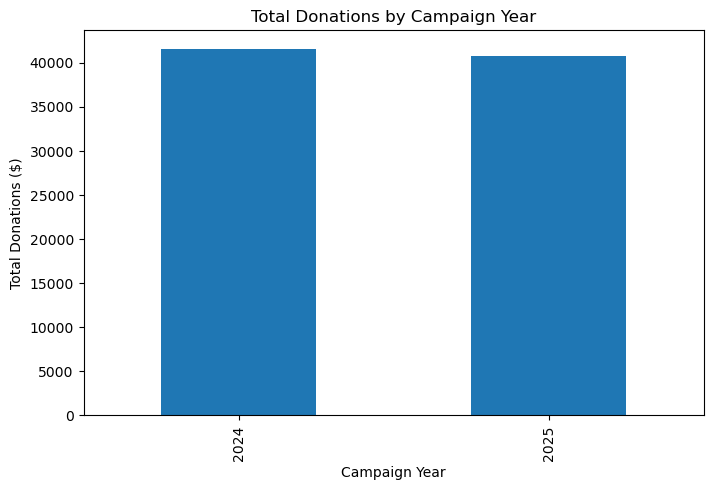

In [66]:
donations_by_year.plot(
    kind="bar",
    figsize=(8,5),
    title="Total Donations by Campaign Year",
    xlabel="Campaign Year",
    ylabel="Total Donations ($)"
)

### Step 28 Chart Insight

The bar chart shows the total donation amounts raised for each campaign year.

**Interpretation:**

Comparing campaign performance across years displays fundraising efforts are declining.

This insight can guide future campaign strategies and outreach efforts.

## Step 29 — Top Donors by Total Donation Amount

**Goal:**

Identify the donors who contributed the most overall (across multiple donations).

**Method:**

1) Create a donor_id using first_name + last_name
2) Group by donor_id and sum donation_amount
3) Sort descending and take the top N donors

**Note:**

This is an approximation because name-based matching can merge different people with the same name.

In [67]:
donation_log_all["donor_id"] = (
    donation_log_all["first_name"].astype("string").str.strip().str.lower()
    + "_"
    + donation_log_all["last_name"].astype("string").str.strip().str.lower()
)

top_donors = (
    donation_log_all
    .groupby("donor_id")["donation_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_donors

donor_id
bob_gault            5000
serge_reiss          2150
albert_nocciolino    2000
lillian_levy         2000
aby_mathew           2000
amelia_buran         2000
marise_mahon         1600
leah_cunningham      1500
thomas_babcock       1200
allan_eagles         1000
Name: donation_amount, dtype: Int64

### Output / Result (Step 29)

The table above lists the top donors based on total donated amount.

**Interpretation:**

These donors are strong supporters and may be ideal for:
- recognition
- personalized outreach
- retention strategies

## Step 30 Visualization — Top 10 Donors by Total Donation Amount

This chart highlights the top donors by total donation amount (sum of gifts).

It supports donor recognition and targeted stewardship efforts.

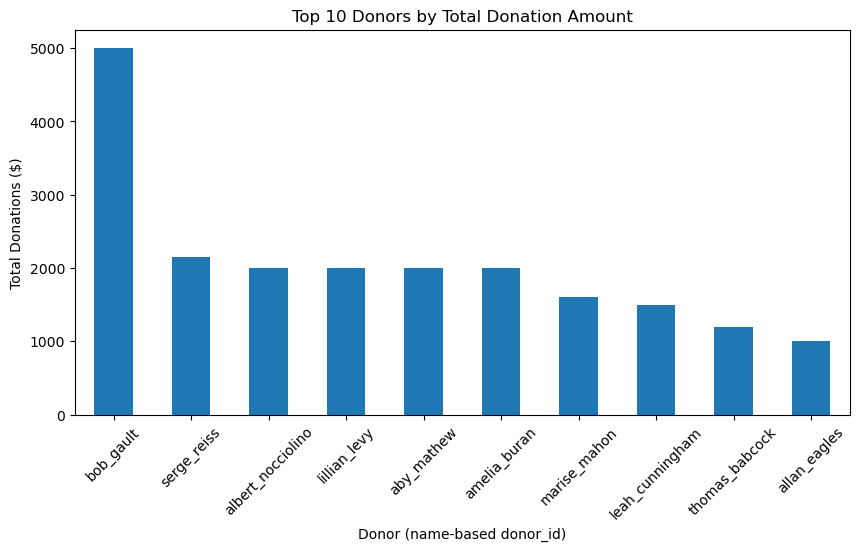

In [68]:
ax = top_donors.plot(kind="bar", figsize=(10,5), title="Top 10 Donors by Total Donation Amount")
ax.set_xlabel("Donor (name-based donor_id)")
ax.set_ylabel("Total Donations ($)")
ax.tick_params(axis="x", rotation=45)

## Step 31 Visualization — Donation Frequency per Donor (All Campaign Data)

**Goal:**

Estimate donor repeat behavior by counting how many donation records each donor has.

**Method:**

- Use donor_id (first + last)
- Count number of rows (donations) per donor
- Visualize distribution of donation counts

**Note:**

This does not require dates. Each row is treated as one donation record.

In [69]:
donation_counts = (
    donation_log_all
    .groupby("donor_id")
    .size()
    .sort_values(ascending=False)
)

donation_counts.describe()

count    94.000000
mean      1.297872
std       0.504385
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max       3.000000
dtype: float64

### Output / Result (Donation Frequency Summary)

The summary stats describe how many donations donors make.

**Key interpretation:**

- If many donors have count = 1 → mostly one-time donors
- If many donors have count >= 2 → meaningful repeat-donor behavior

## Step 32 Visualization — How Many Donors Gave 1x vs 2x vs 3x+

This chart shows the number of donors by donation frequency.

**Purpose:**

Helps identify one-time vs repeat donors for retention strategy.

<Axes: title={'center': 'Donors by Number of Donations'}>

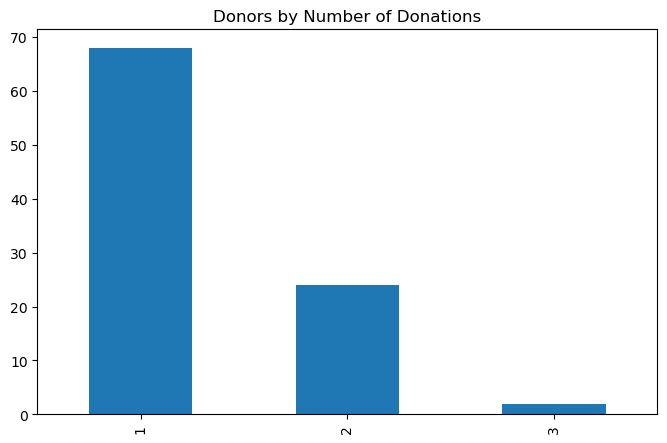

In [70]:
freq_table = donation_counts.value_counts().sort_index()
freq_table.plot(kind="bar", figsize=(8,5), title="Donors by Number of Donations")

### Chart Insight

This distribution shows whether the donor base is mostly one-time donors
or includes a strong repeat-donor segment.

A large count at “1” suggests an opportunity to improve retention and recurring giving.

## Step 33A — Re-load Dated Campaign File (Keep Date)

**Issue:**

The `Date` column disappeared because I sliced only the first 3 columns.

**Fix:**

Re-load the dated file and keep the Date column in addition to name + amount.

**Result:**

A donations table that supports monthly trend and repeat-donor analysis.

In [ ]:
dated_raw = pd.read_excel(file_2025, header=None)  
dated_raw.shape, dated_raw.head()

## Step 33B — Create Dated Donations Table (Keep Date Column)

**Discovery:**

In the dated campaign file, the Date values are stored in column index 7.
Name + amount fields are stored in columns 0, 1, and 2.

**Goal:**

Create a clean table with:
- Date
- last_name
- first_name
- donation_amount

This table will power monthly donor trends and repeat-donor analysis.

In [71]:
donations_dated = pd.read_excel(file_2025, header=None).iloc[:, [7, 0, 1, 2]].copy()
donations_dated.columns = ["Date", "last_name", "first_name", "donation_amount"]

donations_dated.head()

,Date,last_name,first_name,donation_amount
0,Date,Last Name,First Name,Amount
1,NaN,NaN,NaN,NaN
2,2025-04-05 00:00:00,Lia,Diane,50
3,2025-04-07 00:00:00,Gardiner,Matthew,5
4,2025-04-16 00:00:00,Babcock,Thomas,400


### Output / Result (Step 34B)

Built a clean dated donations table with the required fields:

- Date
- last_name
- first_name
- donation_amount

**Next:**

Parse Date → datetime and compute monthly donor activity.

## Step 33C — Monthly Unique Donors (Dated File Only)

**Goal:**

Compute how many unique donors donated each month (dated source only).

**Method:**

- Parse Date into datetime
- Create donor_id (first + last)
- Group by month and count unique donors

In [72]:
donations_dated["donation_amount"] = (
    donations_dated["donation_amount"]
    .astype("string")
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
)
donations_dated["donation_amount"] = pd.to_numeric(donations_dated["donation_amount"], errors="coerce")

donations_dated["date"] = pd.to_datetime(donations_dated["Date"], errors="coerce")

donations_dated["donor_id"] = (
    donations_dated["first_name"].astype("string").str.strip().str.lower()
    + "_"
    + donations_dated["last_name"].astype("string").str.strip().str.lower()
)

dated_valid = donations_dated.dropna(subset=["date"]).copy()
dated_valid["month"] = dated_valid["date"].dt.to_period("M").astype(str)

monthly_unique = (
    dated_valid
    .groupby("month")["donor_id"]
    .nunique()
    .sort_index()
)

monthly_unique

/tmp/ipykernel_3120/2721000078.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  donations_dated["date"] = pd.to_datetime(donations_dated["Date"], errors="coerce")


month
2025-04     3
2025-07     1
2025-09     1
2025-10     1
2025-11     9
2025-12    39
2026-01     6
Name: donor_id, dtype: int64

### Output / Result (Step 33C)

Monthly unique donors were calculated from the dated campaign file.

- Months included: **April, July, September, October, November, December, January**
- Highest donor-activity month: **December** with **39** unique donors

Interpretation:
This shows when donor activity increases or decreases across months (dated source only).

In [ ]:
monthly_unique.plot(kind="line", marker="o", figsize=(10,5), title="Monthly Unique Donors (Dated Source)")

### Chart Insight (Monthly Unique Donors)

Peaks indicate months with higher donor participation, which can guide:

- timing of future outreach
- campaign planning
- volunteer/event scheduling

**Note:**

This trend reflects only the portion of records that include valid dates.

## Export graphs as PNG (for slides)

**Goal:**

Save clean, high-resolution versions of key charts as PNG files so they can be dropped into the team presentation.

In [73]:
from pathlib import Path

FIG_DIR = (BASE_DIR / "outputs" / "figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR

PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/outputs/figures')

In [74]:
import matplotlib.pyplot as plt

## Chart 1 — Top 10 Donors by Total Donation Amount

**Why this chart:**

Shows the highest-value donors and supports donor appreciation + retention strategies.

In [75]:
ax = top_donors.plot(kind="bar", figsize=(10,5), title="Top 10 Donors by Total Donation Amount")
ax.set_xlabel("Donor (name-based donor_id)")
ax.set_ylabel("Total Donations ($)")
ax.tick_params(axis="x", rotation=45)

outpath = FIG_DIR / "chart_top10_donors.png"
ax.figure.savefig(outpath, dpi=200, bbox_inches="tight")
plt.close(ax.figure)

outpath

PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/outputs/figures/chart_top10_donors.png')

## Chart 2 — Donors by Number of Donations (Repeat Donor Signal)

**Why this chart:**

Shows how many donors are one-time vs repeat donors (retention opportunity).

In [76]:
donation_counts = donation_log_all.groupby("donor_id").size()
freq_table = donation_counts.value_counts().sort_index()

ax = freq_table.plot(kind="bar", figsize=(9,5), title="Donors by Number of Donations")
ax.set_xlabel("Number of Donations")
ax.set_ylabel("Number of Donors")

outpath = FIG_DIR / "chart_donation_frequency.png"
ax.figure.savefig(outpath, dpi=200, bbox_inches="tight")
plt.close(ax.figure)

outpath

PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/outputs/figures/chart_donation_frequency.png')

## Chart 2 — Monthly Unique Donors (Dated Campaign File)

**Why this chart:**

Shows how donor participation changes month-to-month.
This supports planning event timing + retention outreach during peak periods.

In [78]:
ax = monthly_unique.plot(kind="line", marker="o", figsize=(10,5), title="Monthly Unique Donors (Dated Source)")
ax.set_xlabel("Month")
ax.set_ylabel("Unique Donors")

outpath = FIG_DIR / "chart_monthly_unique_donors.png"
ax.figure.savefig(outpath, dpi=200, bbox_inches="tight")
plt.close(ax.figure)

outpath

PosixPath('/home/ce5b4deb-dc9a-4dd7-9a99-cd66f2b354ff/BGC_donor_project/outputs/figures/chart_monthly_unique_donors.png')